In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from geoai.utils_ds.DataFrameOps import DataFrameOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ml.ModelOps import ModelOperations

df_ops = DataFrameOperations()
vis_ops = VisualizeOperations()
pre_ops = PreProcessingOperations()
model_ops = ModelOperations()

# Load CSV containing S2 Bands
BLUE, GREEN, RED, NIR, SWIR

In [3]:
X_train = pd.read_csv("csv_files/X_train.csv")
X_test = pd.read_csv("csv_files/X_test.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR
0,373.5,519.5,389.0,3034.0,1991.0


In [4]:
# scale the data
X_train_scaled, X_test_scaled = pre_ops.scale_to_minmax(X_train, X_test)

In [5]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

# Types of Accuracy

- Accuracy: Good for balanced classes but can be misleading if classes are imbalanced.
- Precision: Indicates the quality of positive predictions.
- Recall (Sensitivity): Indicates the coverage of actual positive instances.
- F1 Score: Balances precision and recall, making it useful for imbalanced classes.

In [7]:
# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.9028423772609819, 0.9070430825293643, 0.9028423772609819, 0.903549484077052)
Test Accuracy: (0.8822314049586777, 0.8860260000138163, 0.8822314049586777, 0.8831884437928754)


# Confusion matrix

- True Positive (TP): The number of instances that were correctly classified.
- False Positive (FP): The number of instances that were incorrectly classified as a given class.
- False Negative (FN): The number of instances that were incorrectly classified as another class.
- True Negative (TN): The number of instances that were correctly not classified as a given class.

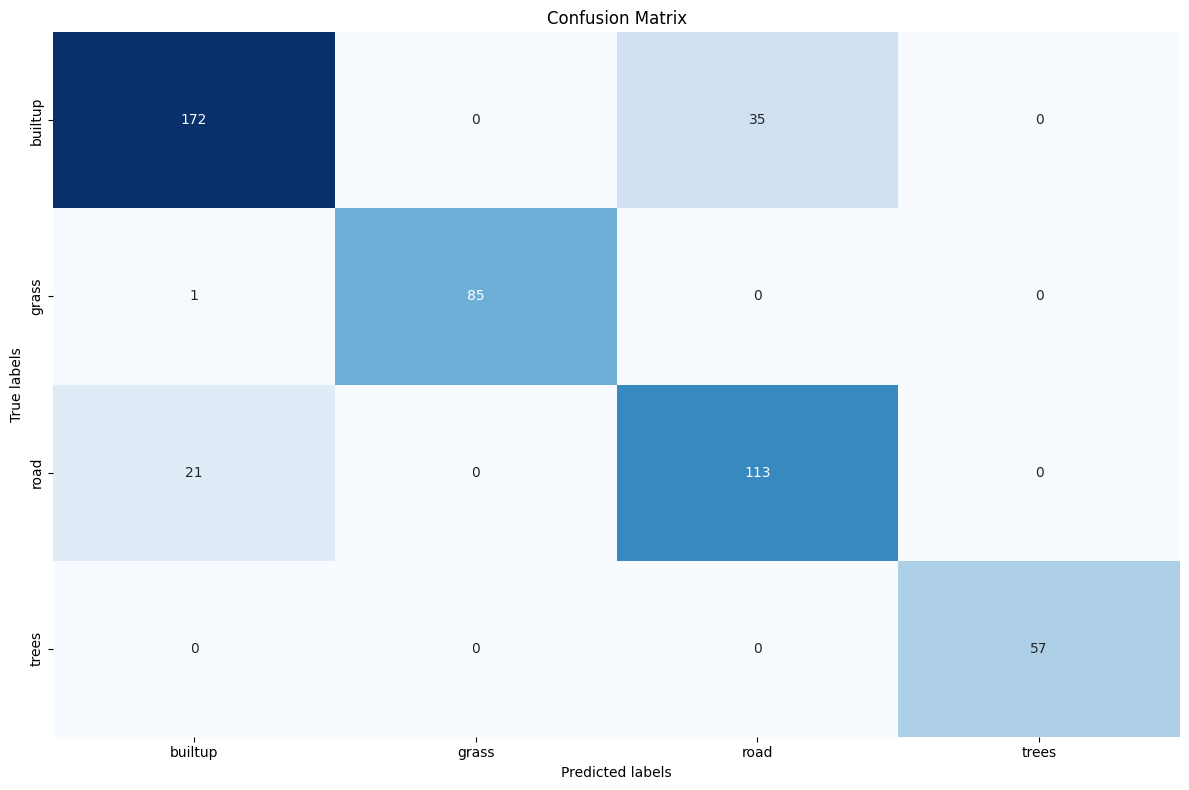

In [8]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]

vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

END